# Set data directory

In [1]:
path = './data/'
path = '../publication/dltest/' ## THIS IS ONLY FOR TESTING

# Preamble

Install the necessary packages:

In [ ]:
%pip install tol-colors
%pip install aseMolec
%pip install ase
%pip install pandas
%pip install numpy
%pip install matplotlib

In [14]:
from ase.io import read, iread
import ase.units
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from aseMolec import pltProps as pp
from aseMolec import anaAtoms as aa
import pandas as pd
import numpy as np
import tol_colors as tc
cset = tc.tol_cset('bright')
plt.rc('axes', prop_cycle=plt.cycler('color', list(cset)))


tags = [
    'Clusters-Small/wB97XD3/SEED1/DSET1',
    'Clusters-Small/wB97XD3/SEED1/DSET2',
    'Clusters-Small/wB97XD3/SEED1/DSET3',
    'Clusters-Small/B97D3/SEED1/DSET1',
    'Clusters-Small/B97D3/SEED1/DSET2',
    'Clusters-Small/B97D3/SEED1/DSET3',
    'Clusters-Small/wB97XD3/SEED2/DSET1',
    'Clusters-Small/wB97XD3/SEED3/DSET1',
    'Clusters-Medium/wB97XD3/SEED1/DSET1',
    'Clusters-Medium/wB97XD3/SEED1/DSET2',
    'Clusters-Medium/wB97XD3/SEED1/DSET3',
    'Clusters-Medium/B97D3/SEED1/DSET1',
    'Clusters-Medium/B97D3/SEED1/DSET2',
    'Clusters-Medium/B97D3/SEED1/DSET3',
    'Clusters-Medium/wB97XD3/SEED2/DSET1',
    'Clusters-Medium/wB97XD3/SEED3/DSET1',
    'Clusters-Large/wB97XD3/SEED1/DSET1',
    'Clusters-Large/wB97XD3/SEED2/DSET1',
    'Clusters-Large/wB97XD3/SEED3/DSET1',
]


small_pkl = './clusters-small_xyz.pkl'
medium_pkl = './clusters-medium_xyz.pkl'
large_pkl = './clusters-large_xyz.pkl'

scale = 2.5
fsize = 8*scale
plt.rcParams.update({'font.size': fsize})

In [3]:
label_map = {
    'B97D3':'B97-D3',
    'wB97XD3':'wB97X-D3',
}

comp_map = {
    '000conEC':'EMC',
    '033conEC':'EC:EMC (3:7)',
    '066conEC':'EC:EMC (7:3)',
    '100conEC':'EC',
}

traj_map = {
    'npt_000conEC_298K':'EMC',
    'npt_033conEC_298K':'EC:EMC (3:7)',
    'npt_066conEC_298K':'EC:EMC (7:3)',
    'npt_100conEC_313K':'EC',
}

model_map = { # ???????????
    'IBM23_PBED3':'PBE-D3',
    'IBM23_PBED2':'PBE-D2',
    'IBM23_B97D3':'B97-D3',
}

data_map = { # ?????????????
    'SDN22N':'Clusters-Large',
    'SDN22NQ':'Clusters-Medium',
    'SDN22NQQ':'Clusters-Small',
    'IBM23':'Periodic',
}

In [4]:
def get_dynamic_data(data, handle=''):
    """Collect time (fs) and MSD (Å/fs) vectors.
    
    This function can be modified to treat any data based on the handle-variable.
    """
    if handle in ('B97D3', 'PBED3', 'PBED2', 'Clusters-Large', 'Clusters-Medium', 'Clusters-Small'):
        time = data['Time']['data']
        msd = data['MSD']['data']
        density = data['Density']['data']
    return time, msd, density


def get_trajectory_results(thermo, threshold=5e-2, window=2000, handle=None):
    results = {
        'Data set':[],
        'Labels':[],
        'Seed ID':[],
        'Sample ID':[],
        'Composition':[],
        'Temperature /K':[],
        'Density /g*cm-3':[],
        'Density std. /g*cm-3':[],
        'Diff. coeff. /1e6 cm2*s-1':[],
        'Diff. fit slope error /1e6 cm2*s-1':[],
        'Diff. fit R2':[],
        'Start time /ns':[],
        'Start time R2':[],
    }
    print(f'Using slope error thresold of: {threshold}, and moving window of: {window} frames')
    for i, tag in enumerate(thermo):
        print()
        print(tag)
        data_set, labels, seed, dset_sample = tag.split('/')
        seed_id = int(seed[-1])
        sample_id = int(dset_sample[-1])
        for j, (traj_name, traj_data) in enumerate(thermo[tag].items()):
            print(traj_name)
            ensemble, comp, temp = traj_name.split('_')
            temp = int(temp[:-1])
            
            # Collect data
            ## If loading data from sources with a different structure from this, this must be controlled using
            ## the handle-variable. In such case, get_dynamic_data must also be modified to accomodate this.
            if handle == 'Labels':
                time, msd, density = get_dynamic_data(traj_data, handle=labels)
            elif handle == 'Data set':
                time, msd, density = get_dynamic_data(traj_data, handle=data_set)

            # Obtain optimal starting time from unit log-log slope by fitting slopes in a moving window
            start_index, start_time_R2 = get_start_index(time, msd, threshold=threshold, window=window, start_id=0)

            if start_index != None:
                # Obtain diffusion coefficient with fitting errors
                diffusion_coeff, slope_error, diffusion_coeff_R2 = diffusion_coefficient(time[start_index:],msd[start_index:])
                print(f'start index: {start_index}, time steps: {len(time)}, start time R2: {start_time_R2:.5f}, Diff. coeff. (m^2/s): {diffusion_coeff:.5e}, slope error: {slope_error:.5e}, Diff. coeff. R2: {diffusion_coeff_R2:.5f}')
                
                results['Data set'].append(data_set)
                results['Labels'].append(label_map[labels])
                results['Seed ID'].append(seed_id)
                results['Sample ID'].append(sample_id)
                results['Composition'].append(comp_map[comp])
                results['Temperature /K'].append(temp)
                results['Density /g*cm-3'].append(np.mean(density))
                results['Density std. /g*cm-3'].append(np.std(density))
                results['Diff. coeff. /1e6 cm2*s-1'].append(diffusion_coeff*1e10)
                results['Diff. fit slope error /1e6 cm2*s-1'].append(slope_error*1e10)
                results['Diff. fit R2'].append(diffusion_coeff_R2)
                results['Start time /ns'].append(time[start_index]*1e-6)
                results['Start time R2'].append(start_time_R2)
            else:
                results['Data set'].append(np.nan)
                results['Labels'].append(np.nan)
                results['Seed ID'].append(np.nan)
                results['Sample ID'].append(np.nan)
                results['Composition'].append(np.nan)
                results['Temperature /K'].append(np.nan)
                results['Density /g*cm-3'].append(np.nan)
                results['Density std. /g*cm-3'].append(np.nan)
                results['Diff. coeff. /1e6 cm2*s-1'].append(np.nan)
                results['Diff. fit slope error /1e6 cm2*s-1'].append(np.nan)
                results['Diff. fit R2'].append(np.nan)
                results['Start time /ns'].append(np.nan)
                results['Start time R2'].append(np.nan)
    df = pd.DataFrame(results)
    return df


def get_xyz(tag, handle='xyz'):
    import glob
    flist = [name for name in glob.glob(tag)]
    for f in flist:
        if handle in f:
            print(f)
            return read(f, ':')


def RMSE(x,y):
    rmse = np.sqrt(np.mean((x-y)**2))
    rrmse = rmse/np.sqrt(np.mean((x-np.mean(x))**2))
    return rmse, rrmse


def get_all_thermo(tag, handle='.thermo'):
    """This needs to be exhanged for Ioans version in order to be consistent with
    zenodo.
    """
    import glob
    import os
    from aseMolec import pltProps as pp
    
    thermo = {}
    flist = [name for name in glob.glob(tag) if handle in name]
    for f in flist:
        print(f)
        aux = os.path.basename(f)
        key = os.path.splitext(aux)[0]
        if 'xyz' in handle:
            thermo.update({key: read(f, ':')})
        else:
            thermo.update({key: pp.loadtxttag(f)})
    return thermo


def diffusion_coefficient(time, msd):
    """Determines the diffusion coefficient in three dimensions
    from the slope of the MSD-curve.
    """
    from scipy.stats import linregress

    res = linregress(time,msd)
    diffusion_coeff = res.slope/6 #final unit: A^2/fs
    diffusion_coeff *= 1e-5 #final unit: m^2/s
    diffusion_err = res.stderr*1e-5 #final unit: m^2/s

    # Two-sided t-test for error in slope
    from scipy.stats import t
    tinv = lambda p, df: abs(t.ppf(p/2, df))
    ts = tinv(0.05, len(time)-2)
    return diffusion_coeff, ts*diffusion_err, res.rvalue**2


def get_slope(time, msd):
    from scipy.stats import linregress
    res = linregress(time,msd)
    return res.slope, res.intercept, res.stderr, res.rvalue**2


def get_start_index(time, msd, threshold, window, start_id=0):
    window = int(window)
    start_id = int(start_id)
    ids = {}
    for i, t in enumerate(time[start_id:]):
        if i > window:
            
            slope, intercept, err, r2 = get_slope(np.log(time[i:i+window]),np.log(msd[i:i+window]))
            if abs(slope-1) < threshold:
                ids[start_id+i] = r2
    idx, r2 = max(ids.items(), key=lambda x: x[1])
    return idx, r2


def rvalue_formatting(x):
    if x < 0.8:
        return 'background-color: red'
    elif x < 0.9:
        return 'background-color: orange'
    elif x < 0.95:
        return 'background-color: yellow'
    else:
        return None

def rvalue_formatting_latex(x, trunc=6):
    if x < 0.8:
        return r'\color{RED}'+str(x)[:trunc]
    elif x < 0.9:
        return r'\color{ORANGE}'+str(x)[:trunc]
    elif x < 0.95:
        return r'\color{YELLOW}'+str(x)[:trunc]
    else:
        return str(x)[:trunc]

def get_colour(name):
    colmap = {
        'EMC':'blue',
        'EC:EMC (3:7)':'green',
        'EC:EMC (7:3)':'yellow',
        'EC':'red',
    }
    return getattr(cset, colmap[name])


def get_mol_positions(atoms):
	positions = []
	mol_set = set(atoms.arrays['molID'])
	for ID in mol_set:
		mol = atoms[atoms.arrays['molID'] == ID]
		com = mol.get_center_of_mass()
		positions.append(com)
	positions = np.array(positions)
	return positions


def mol_rdf(atoms, rmax, nbins, return_num_mols=False):
	positions = get_mol_positions(atoms)
	nmols, dim = positions.shape
	box_length = atoms.get_volume()**(1/3)
	for i, p in enumerate(positions):
		# PBC
		delta = positions[i+1:]-positions[i]
		delta -= box_length*np.round(delta/box_length)
		
		# Get counts
		dists = np.linalg.norm(delta, axis=1)
		s = sorted(dists[dists <= rmax])[1:]
		if i == 0:
			counts, bins = np.histogram(s, nbins, (0,rmax))
		else:
			counts += np.histogram(s, nbins, (0,rmax))[0]

	if return_num_mols:
		return counts, bins, nmols
	else:
		return counts, bins
     

def compute_mol_rdf(traj, rmax=None, nbins=100, return_rho=False):
	for i, atoms in enumerate(traj):
		if i == 0:
			counts, bins, nmols = mol_rdf(atoms, rmax=rmax, nbins=nbins, return_num_mols=True)
			volume = atoms.get_volume()
			box_length = volume**(1/3)
			r = 0.5*(bins[1:]+bins[:-1])
		else:
			counts += mol_rdf(atoms, rmax=rmax, nbins=nbins)[0]
	
	num_snapshots = i+1
	nvalid = nmols/2
	n_k = counts/(nvalid*num_snapshots)	
	dr = rmax/nbins
	shell_volumes = 4/3*np.pi*((r+dr)**3-r**3)
	rho = nmols/volume
	
	g = n_k/(rho*shell_volumes)
	if return_rho:
		return g, r, rho
	else:
		return g, r


def get_mol_rdfs(path, tags, slice=':'):
    import glob
    from aseMolec import anaAtoms as aa

    rdfs = {}
    number_densities = {}
    for tag in tags:
        data_set, labels, seed, dset_sample = tag.split('/')
        flist = [name for name in glob.glob(f'{path}{tag}/dynamics/*') if '.xyz' in name]
        name = f'{data_set}_{labels}'
        print(name, dset_sample, seed)

        for file in flist:
            print(file)
            comp = file.split('/')[-1].split('.')[0][4:-5]
            comp = comp_map[comp]
            traj = read(file, slice)
            aa.find_molecs(traj, fct=1.0)
            g, r, rho = compute_mol_rdf(traj, rmax=11, return_rho=True)

            if name not in rdfs:
                rdfs[name] = {}
            if dset_sample not in rdfs[name]:
                rdfs[name][dset_sample] = {}
            if seed not in rdfs[name][dset_sample]:
                rdfs[name][dset_sample][seed] = {}
            
            if name not in number_densities:
                number_densities[name] = {}
            if dset_sample not in number_densities[name]:
                number_densities[name][dset_sample] = {}
            if seed not in number_densities[name][dset_sample]:
                number_densities[name][dset_sample][seed] = {}

            rdfs[name][dset_sample][seed][comp] = [g, r]
            number_densities[name][dset_sample][seed][comp] = rho
            del traj
    
    return rdfs, number_densities

def get_indices_of_sign_change(lst):
    arr = np.array(lst)
    sign_changes = np.where(np.diff(np.sign(arr)) != 0)[0]
    return sign_changes








def yaml_to_multidf(fname, index_list):
    import yaml
    import pandas as pd
    
    # Load YAML
    with open(fname, "r") as f:
        raw = yaml.safe_load(f)
    f.close()

    # Convert to DataFrame
    df = pd.DataFrame(raw['metadata'])

    # Set MultiIndex
    df = df.set_index(index_list)
    return df


def download_file(url, output_file):
	import requests
	from pathlib import Path
	print(f"Downloading {url} -> {output_file}")
	response = requests.get(url)
	response.raise_for_status()

	Path(output_file).parent.mkdir(parents=True, exist_ok=True)

	with open(output_file, "wb") as f:
		f.write(response.content)


def unzip_file(zip_path, extract_to):
	from pathlib import Path
	import zipfile
	print(zip_path)
	print(f"Unzipping {zip_path} -> {extract_to}")
	Path(extract_to).mkdir(parents=True, exist_ok=True)

	with zipfile.ZipFile(zip_path, "r") as z:
		z.extractall(extract_to)


def download_unpack(root, config_path, key):
	import yaml; import os.path
	with open(root+config_path, "r") as f:
		config = yaml.safe_load(f)

	for item in config[key]:
		url = item["url"]
		output_file = item["output_file"]
		extract_to = item["extract_to"]

		if not os.path.isfile(root+output_file):
			download_file(url, root+output_file)
		unzip_file(root+output_file, root+extract_to)


def flatten_results(df, prop_handle, merge_type):
    if merge_type == 'mean':
        return df[prop_handle].mean()
    elif merge_type == 'std':
        return df[prop_handle].std()


def get_committee_results(df, group_by, droplist):
    dfs = []
    for group_name, group in df.groupby(group_by):
        tmp = []
        for comp_name, comp in group.groupby('Composition'):
            t = comp.iloc[0].copy()
            t['Density /g*cm-3'] = flatten_results(comp, 'Density /g*cm-3', merge_type='mean')
            t['Density std. /g*cm-3'] = flatten_results(comp, 'Density /g*cm-3', merge_type='std')
            t['Diff. coeff. /1e6 cm2*s-1'] = flatten_results(comp, 'Diff. coeff. /1e6 cm2*s-1', merge_type='mean')
            t['Diff. fit slope error /1e6 cm2*s-1'] = flatten_results(comp, 'Diff. coeff. /1e6 cm2*s-1', merge_type='std')
            t = t.drop(droplist)
            tmp.append(t)
        dfs.append(pd.DataFrame(tmp)) 
    return pd.concat(dfs)



In [ ]:
def self_interaction_mask(array):
    SI = [[0 if a==b else 1 for b in array] for a in array]
    return np.array(SI)


def get_pair_histogram(atoms, rmax, nbins, pbc, probability=False, inter_only=False, threshold=None, molIDs=None):
    if pbc:
        distances = atoms.get_all_distances(mic=True)
    else:
        distances = atoms.get_all_distances()
    
    if inter_only and (molIDs is not None):
        distances = distances*self_interaction_mask(molIDs)
        
        if threshold is not None:
            ids = np.where((distances>0) & (distances<threshold))[0]
            if len(ids) > 0:
                print(ids)

        iu = np.triu_indices(len(distances), k=1)
        dists = distances[iu]
        del iu
    else:
        dists = distances
    
    dr = rmax/nbins
    edges = np.arange(0, rmax+dr, dr)
    counts, bins = np.histogram(dists, bins=edges)
    counts[0] = 0
    r = 0.5*(bins[1:]+bins[:-1])
    n_r = counts/(len(atoms)-1)
    del atoms
    del dists

    if probability:
        p_r = n_r/np.cumsum(n_r)*dr
        return p_r, r
    else:
        return n_r, r


def compute_rdf(atoms, rmax=None, nbins=100, rho=None, return_rho=False, nbr_density=False, pbc=True, probability=False, inter_only=False, use_max=False, threshold=None):
    if inter_only and ('molID' not in atoms[0].arrays):
        aa.find_molecs(atoms, fct=1.0)
        
    for i, a in enumerate(atoms):
        if inter_only and ('molID' in a.arrays):
            molIDs = a.arrays['molID']
        else:
            molIDs = None

        
        if (rho is None) and (nbr_density is False):
            rho = len(a)/a.get_volume()
        elif nbr_density is True:
            rho = 1

        if i == 0:
            counts, r = get_pair_histogram(a, rmax=rmax, nbins=nbins, pbc=pbc, probability=probability, inter_only=inter_only, threshold=threshold, molIDs=molIDs)
            max_counts = counts
            max_rho = rho
        else:
            new_counts = get_pair_histogram(a, rmax=rmax, nbins=nbins, pbc=pbc, probability=probability, inter_only=inter_only, threshold=threshold, molIDs=molIDs)[0]
            max_counts = np.maximum(max_counts, new_counts)
            max_rho = max(max_rho, rho)
            counts += new_counts
        del a

    num_images = len(atoms)
    dr = rmax/nbins
    
    if use_max:
        counts = max_counts
        n_k = 2*counts
        rho = max_rho
    else:
        n_k = 2*counts/num_images

    n_ideal = 4/3*np.pi*((r+dr)**3-r**3)*rho
    
    if nbr_density:
        g = n_k
    else:
        g = n_k/n_ideal
    
    if return_rho:
        return g, r, rho
    else:
        return g, r


def average_nbr_distribution(xyz_dict, rmax, nbins, inter_only, use_max, pbc):
    kwargs = dict(
        rmax=rmax, nbins=nbins, 
        inter_only=inter_only, use_max=use_max,
        pbc=pbc,
    )
    g = 0; n = 0; r = 0; rho = 0
    print('Evaluating:')
    for i, (key, atoms) in enumerate(xyz_dict.items()):
        print(key)
        g_prime, r, rho_prime = compute_rdf(atoms, nbr_density=False, return_rho=True, **kwargs)
        n_prime, _ = compute_rdf(atoms, nbr_density=True, return_rho=False, **kwargs)
        g += g_prime
        n += n_prime
        rho += rho_prime
    g /= i+1
    n /= i+1
    rho /= i+1
    print('Done!')
    return {
        'RDF':(g, r, rho),
        'Nbrs':(n, r),
    }

# Download
## MLIP data

In [ ]:
download_unpack(path, "clusters_metadata.yaml", "MLIP downloads")

## MD simulation data

In [ ]:
download_unpack(path, "clusters_metadata.yaml", "MDSims downloads")

## Data overview

In [5]:
meta_df = yaml_to_multidf(path+"clusters_metadata.yaml", ["Labels", "Parent data", "Data set"])
meta_df

Subset  Seeds  Number of structures  \
Labels   Parent data     Data set                                               
wB97X-D3 Clusters-Full   Clusters-Large        1      3                221824   
         Clusters-Large  Clusters-Medium       1      3                 42824   
                         Clusters-Medium       2      1                 42824   
                         Clusters-Medium       3      1                 42824   
         Clusters-Medium Clusters-Small        1      3                  8016   
                         Clusters-Small        2      1                  8016   
                         Clusters-Small        3      1                  8016   
B97-D3   Clusters-Large  Clusters-Medium       1      1                 42824   
                         Clusters-Medium       2      1                 42824   
                         Clusters-Medium       3      1                 42824   
         Clusters-Medium Clusters-Small        1      1                  8016   
                         Clusters-Small        2      1                  8016   
                         Clusters-Small        3      1                  8016   

                                          Number of atoms  
Labels   Parent data     Data set                          
wB97X-D3 Clusters-Full   Clusters-Large           4805916  
         Clusters-Large  Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
         Clusters-Medium Clusters-Small            327089  
                         Clusters-Small            327089  
                         Clusters-Small            327089  
B97-D3   Clusters-Large  Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
         Clusters-Medium Clusters-Small            327089  
                         Clusters-Small            327089  
                         Clusters-Small            327089

___
# Results
## NPT dynamics
Load MD output files:

In [ ]:
thermo = dict()
for tag in tags:
    thermo[tag] = get_all_thermo(f'{path}{tag}/dynamics/*', handle='.thermo')

Calculate diffusion coefficients and collect data:

In [ ]:
df = get_trajectory_results(thermo, handle='Data set')
pd.to_pickle(df, './part2_results.pkl')

Results summary:

In [51]:
df = pd.read_pickle('./part2_results.pkl')
df.style.map(rvalue_formatting, subset=['Start time R2', 'Diff. fit R2'])

,Data set,Labels,Seed ID,Sample ID,Composition,Temperature /K,Density /g*cm-3,Density std. /g*cm-3,Diff. coeff. /1e6 cm2*s-1,Diff. fit slope error /1e6 cm2*s-1,Diff. fit R2,Start time /ns,Start time R2
0,Clusters-Small,wB97X-D3,1,1,EMC,298,1.133707,0.015552,3.519126,0.011999,0.992566,0.109040,0.818949
1,Clusters-Small,wB97X-D3,1,1,EC:EMC (3:7),298,1.205010,0.015673,2.459633,0.012300,0.983909,0.095530,0.888563
2,Clusters-Small,wB97X-D3,1,1,EC:EMC (7:3),298,1.283700,0.016119,2.255040,0.013285,0.976908,0.058130,0.909458
3,Clusters-Small,wB97X-D3,1,1,EC,313,1.379088,0.016214,1.758617,0.009244,0.982605,0.113830,0.915480
4,Clusters-Small,wB97X-D3,1,2,EMC,298,1.131117,0.016579,2.514486,0.025086,0.953266,0.129620,0.893847
5,Clusters-Small,wB97X-D3,1,2,EC:EMC (3:7),298,1.201672,0.014779,3.173179,0.019937,0.978340,0.043800,0.921372
6,Clusters-Small,wB97X-D3,1,2,EC:EMC (7:3),298,1.292896,0.016199,1.348932,0.009176,0.976791,0.110490,0.847251
7,Clusters-Small,wB97X-D3,1,2,EC,313,1.384449,0.016043,2.337231,0.011982,0.984953,0.038760,0.964612
8,Clusters-Small,wB97X-D3,1,3,EMC,298,1.117259,0.016536,4.312872,0.026862,0.976756,0.151610,0.879300
9,Clusters-Small,wB97X-D3,1,3,EC:EMC (3:7),298,1.183245,0.016968,2.843554,0.018265,0.971738,0.025140,0.955108


Get committe results:

In [52]:
droplist = [
    'Start time /ns',
    'Diff. fit R2',
    'Start time R2',
    'Sample ID',
    'Seed ID',
]
committee_df = pd.concat([
    get_committee_results(df[df['Labels'] == 'B97-D3'], 'Data set', droplist),
    get_committee_results(df[df['Labels'] == 'wB97X-D3'], 'Data set', droplist),
], ignore_index=True)
committee_df

,Data set,Labels,Composition,Temperature /K,Density /g*cm-3,Density std. /g*cm-3,Diff. coeff. /1e6 cm2*s-1,Diff. fit slope error /1e6 cm2*s-1
0,Clusters-Medium,B97-D3,EC,313,1.171017,0.094790,12.103789,6.931497
1,Clusters-Medium,B97-D3,EC:EMC (3:7),298,0.979340,0.115907,17.710213,12.616159
2,Clusters-Medium,B97-D3,EC:EMC (7:3),298,1.066945,0.110773,13.321529,8.383587
3,Clusters-Medium,B97-D3,EMC,298,0.901534,0.121418,24.807315,14.628144
4,Clusters-Small,B97-D3,EC,313,1.189376,0.042676,9.131780,2.993043
5,Clusters-Small,B97-D3,EC:EMC (3:7),298,1.070961,0.056934,8.361122,4.507261
6,Clusters-Small,B97-D3,EC:EMC (7:3),298,1.127905,0.047926,7.163316,3.254362
7,Clusters-Small,B97-D3,EMC,298,1.024944,0.067614,9.574357,6.470686
8,Clusters-Large,wB97X-D3,EC,313,1.333020,0.057471,3.808168,1.665805
9,Clusters-Large,wB97X-D3,EC:EMC (3:7),298,1.111721,0.048993,7.607601,4.521079


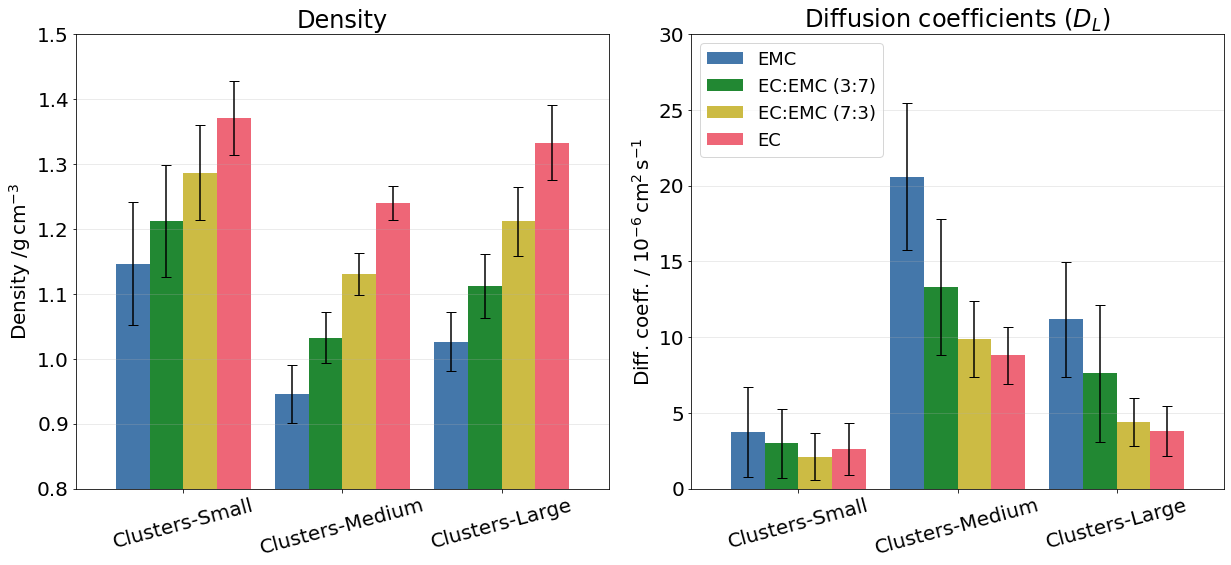

In [14]:
order = [
    'EMC',
    'EC:EMC (3:7)', 
    'EC:EMC (7:3)',
    'EC',
]
group_order = [
    'Clusters-Small',
    'Clusters-Medium',
    'Clusters-Large',
]

plot_df = committee_df[committee_df['Labels'] == 'wB97X-D3']


# Pivot tables for plotting
dens_df = plot_df.pivot(
	index='Data set',
	columns='Composition',
	values='Density /g*cm-3',
).reindex(group_order)[order]
dens_err_df = plot_df.pivot(
	index='Data set',
	columns='Composition',
	values='Density std. /g*cm-3',
).reindex(group_order)[order]

diff_df = plot_df.pivot(
	index='Data set',
	columns='Composition',
	values='Diff. coeff. /1e6 cm2*s-1',
).reindex(group_order)[order]
diff_err_df = plot_df.pivot(
	index='Data set',
	columns='Composition',
	values='Diff. fit slope error /1e6 cm2*s-1',
).reindex(group_order)[order]

fig, axs = plt.subplots(1,2, figsize=(7*scale, 3.3*scale), sharex=True, sharey=False)

a0 = dens_df.plot.bar(
    title='Density',
    ylim=[0.8,1.5],
    ylabel=f'Density /g$\\,$cm$^{{-3}}$',
    xlabel='',
    yerr=dens_err_df,
    capsize=5,
    rot=15,
    width=0.85,
    color=[get_colour(o) for o in order],
    ax=axs[0],
    legend=False,
)
axs[0].grid(axis='y', alpha=0.3)


a1 = diff_df.plot.bar(
    title='Diffusion coefficients ($D_L$)',
    ylim=[0,30],
    ylabel=f'Diff. coeff. / $10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
    xlabel='',
    yerr=diff_err_df,
    capsize=5,
    rot=15,
    width=0.85,
    color=[get_colour(o) for o in order],
    ax=axs[1],
    legend=False,
)
axs[1].grid(axis='y', alpha=0.3)
axs[1].legend(loc='upper left', fontsize=fsize-2)

plt.tight_layout()
#plt.savefig('../publication/plots/part2_committee_results.pdf', format='pdf', dpi=1200)


## Finite size correction of diffusion coefficients
For the diffusion data, we first need to compute the correction coefficients used by [Schrodinger SI, equ 5](https://pubs.acs.org/doi/suppl/10.1021/acs.jpcb.2c03746/suppl_file/jp2c03746_si_001.pdf) and [Bamboo, equ 61](https://arxiv.org/pdf/2404.07181), quoting [standard practice, equ 3](https://livecomsjournal.org/index.php/livecoms/article/view/v1i1e6324/937).
$$
D(\infty)=D(L)+\frac{2.837298\times k_BT}{6\pi \eta L}
$$
Box sizes are computed from number of molecules (table S1) and densities (table S2) from Schrodinger, temperatures are taken from table S1 and viscosity from table S3.

In [17]:
mass_thermo = get_all_thermo(f'{path}{tags[-1]}/dynamics/*', handle='.xyz')

for comp, traj in mass_thermo.items():
    if '000conEC' in comp:
        print('Pure EMC:')
        M_EMC = traj[0].get_masses().sum() # u=g/mol
        m_EMC = M_EMC/ase.units.mol*1e-3 # g/mol*mol/1000=kg
        print(f'Total mass:\t{m_EMC} kg')
    elif '100conEC' in comp:
        print('Pure EC:')
        M_EC = traj[0].get_masses().sum() # u=g/mol
        m_EC = M_EC/ase.units.mol*1e-3 # g/mol*mol/1000=kg
        print(f'Total mass:\t{m_EC} kg')

../publication/dltest/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_000conEC_298K.xyz
../publication/dltest/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_033conEC_298K.xyz
../publication/dltest/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_066conEC_298K.xyz
../publication/dltest/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_100conEC_313K.xyz
Pure EMC:
Total mass:	1.1582317925845882e-23 kg
Pure EC:
Total mass:	1.462303889780969e-23 kg


In [18]:
m_EC = 1.462303889780969e-23 # kg
eta_EC = 1.93e-3 # Pa s
m_EMC = 1.1582317925845882e-23 # kg
eta_EMC = 0.65e-3 # Pa s*
kB = ase.units.kB/ase.units.J
xi = 2.837298
print(f'EMC viscosity:\t{eta_EMC} Pa s (at 298 K)')
print(f'EC viscosity:\t{eta_EC} Pa s (at 313 K)')
print(f'kB:\t\t{kB} J\n')

corr_df = committee_df.copy()
corr_df = corr_df[(corr_df['Composition'] == 'EMC') | (corr_df['Composition'] == 'EC')]
for tag, data in thermo.items():
    data_set, labels, seed, dset = tag.split('/')
    if (seed == 'SEED1') and (dset == 'DSET1'):
        print(tag)

    for comp, traj in data.items():
        temp = int(comp.split('_')[-1][:-1])
        time, msd, dens = get_dynamic_data(traj, handle=data_set)
        dens = np.mean(dens)*1000 # kg/m3

        if ('000conEC' in comp) and (seed == 'SEED1') and (dset == 'DSET1'):
            print('EMC:')
            total_mass = m_EMC
            eta = eta_EMC
            volume = total_mass/dens # m3
            L = volume**(1/3) # m
            corr = xi*kB*temp/(6*np.pi*eta*L) # kT=[J]=[Pa m3] => Pa m3/(Pa s m)=m2/s
        elif ('100conEC' in comp) and (seed == 'SEED1') and (dset == 'DSET1'):
            print('EC:')
            total_mass = m_EC
            eta = eta_EC
            volume = total_mass/dens # m3
            L = volume**(1/3) # m
            corr = xi*kB*temp/(6*np.pi*eta*L) # kT=[J]=[Pa m3] => Pa m3/(Pa s m)=m2/s
        else:
            corr = 0
        
        corr *= 1e10 # 1e-6 cm2/s
        if corr > 0:
            print(f'Box length:\t{L*1e10:.3f} Å')
            print(f'Correction:\t{corr:.3f} 1e-6cm2/s\n')

        data_mask = corr_df['Data set'] == data_set
        func_mask = corr_df['Labels'] == label_map[labels]
        comp_mask = corr_df['Composition'] == traj_map[comp]
        corr_df.loc[data_mask & func_mask & comp_mask, 'Diff. coeff. /1e6 cm2*s-1'] += corr
corr_df.round(decimals=2)

EMC viscosity:	0.00065 Pa s (at 298 K)
EC viscosity:	0.00193 Pa s (at 313 K)
kB:		1.38064852e-23 J

Clusters-Small/wB97XD3/SEED1/DSET1
EMC:
Box length:	21.699 Å
Correction:	4.391 1e-6cm2/s

EC:
Box length:	21.969 Å
Correction:	1.534 1e-6cm2/s

Clusters-Small/B97D3/SEED1/DSET1
EMC:
Box length:	21.936 Å
Correction:	4.343 1e-6cm2/s

EC:
Box length:	22.773 Å
Correction:	1.480 1e-6cm2/s

Clusters-Medium/wB97XD3/SEED1/DSET1
EMC:
Box length:	23.157 Å
Correction:	4.114 1e-6cm2/s

EC:
Box length:	22.806 Å
Correction:	1.478 1e-6cm2/s

Clusters-Medium/B97D3/SEED1/DSET1
EMC:
Box length:	22.325 Å
Correction:	4.268 1e-6cm2/s

EC:
Box length:	22.520 Å
Correction:	1.497 1e-6cm2/s

Clusters-Large/wB97XD3/SEED1/DSET1
EMC:
Box length:	22.104 Å
Correction:	4.310 1e-6cm2/s

EC:
Box length:	21.872 Å
Correction:	1.541 1e-6cm2/s



,Data set,Labels,Composition,Temperature /K,Density /g*cm-3,Density std. /g*cm-3,Diff. coeff. /1e6 cm2*s-1,Diff. fit slope error /1e6 cm2*s-1
0,Clusters-Medium,B97-D3,EC,313,1.17,0.09,13.60,6.93
3,Clusters-Medium,B97-D3,EMC,298,0.90,0.12,29.07,14.63
4,Clusters-Small,B97-D3,EC,313,1.19,0.04,10.61,2.99
7,Clusters-Small,B97-D3,EMC,298,1.02,0.07,13.92,6.47
8,Clusters-Large,wB97X-D3,EC,313,1.33,0.06,5.35,1.67
11,Clusters-Large,wB97X-D3,EMC,298,1.03,0.05,15.49,3.79
12,Clusters-Medium,wB97X-D3,EC,313,1.24,0.03,10.27,1.90
15,Clusters-Medium,wB97X-D3,EMC,298,0.95,0.04,24.69,4.85
16,Clusters-Small,wB97X-D3,EC,313,1.37,0.06,4.16,1.69
19,Clusters-Small,wB97X-D3,EMC,298,1.15,0.09,8.12,2.98


___
# SI

## Density and diffusion
### Effects random seed and sampling

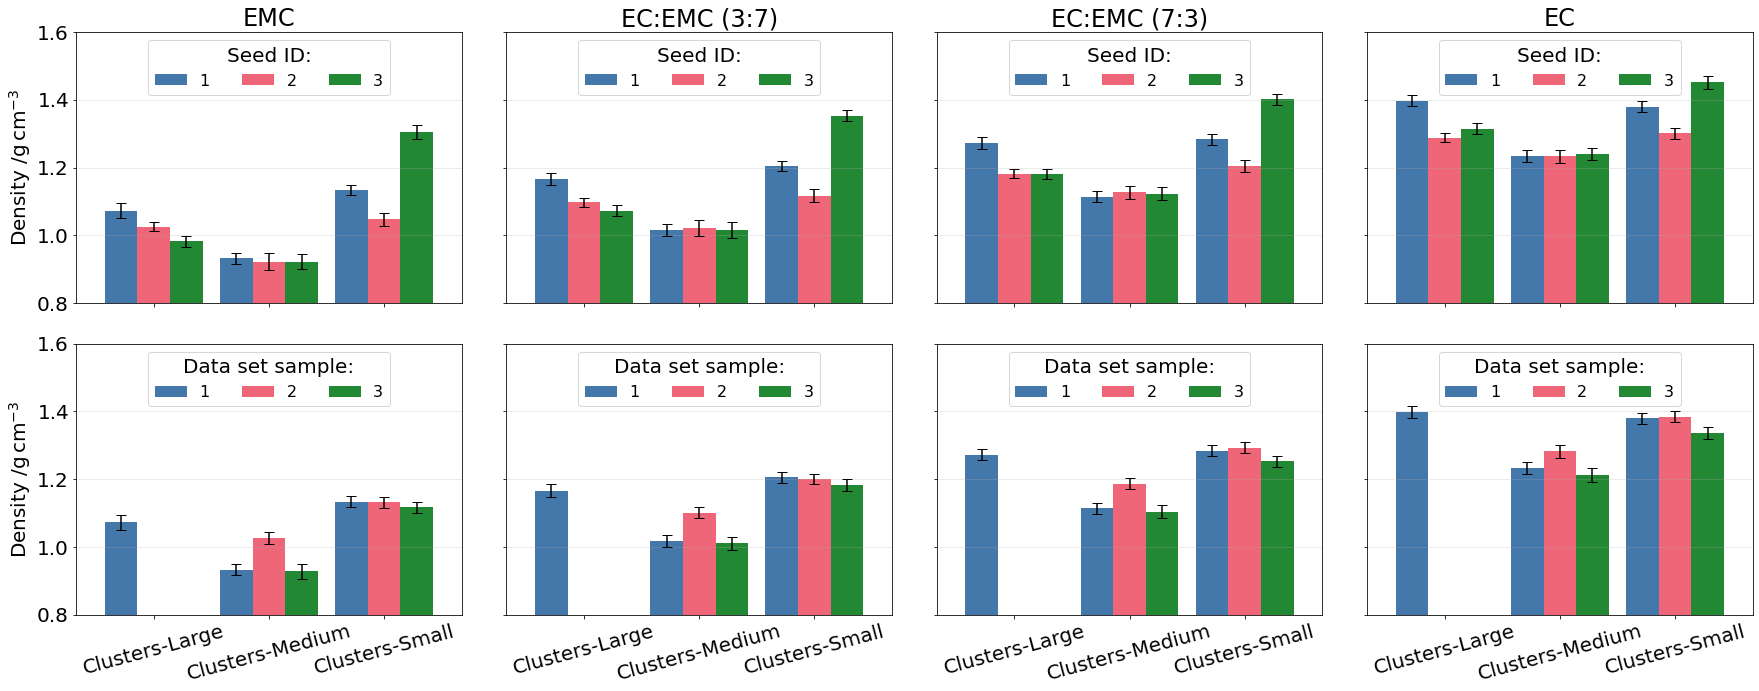

In [ ]:
order = [
    'EMC',
    'EC:EMC (3:7)', 
    'EC:EMC (7:3)',
    'EC',
]
wB97X_df = df.copy()[df['Labels'] == 'wB97X-D3']
wB97X_df['Composition'] = pd.Categorical(wB97X_df['Composition'], categories=order, ordered=True)
wB97X_df = wB97X_df.sort_values('Composition')


fig, axs = plt.subplots(2,4, figsize=(10*scale, 4*scale), sharey='row', sharex='col')

seed_df = wB97X_df[wB97X_df['Sample ID'] == 1]
for ax, (n,g) in zip(axs[0,:], seed_df.groupby('Composition',observed=False)):
    avg_g = g.pivot(
        index='Data set',
        columns='Seed ID',
        values='Density /g*cm-3',
    )
    std_g = g.pivot(
        index='Data set',
        columns='Seed ID',
        values='Density std. /g*cm-3',
    )
    a0 = avg_g.plot.bar(
        title=n,
        ylim=[0.8,1.6],
        ylabel=f'Density /g$\\,$cm$^{{-3}}$',
        yerr=std_g,
        capsize=5,
        rot=15,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Seed ID:', ncols=3, loc='upper center', fontsize=fsize-4)


sample_df = wB97X_df[wB97X_df['Seed ID'] == 1]
for ax, (n,g) in zip(axs[1,:], sample_df.groupby('Composition',observed=False)):
    avg_g = g.pivot(
        index='Data set',
        columns='Sample ID',
        values='Density /g*cm-3',
    )
    std_g = g.pivot(
        index='Data set',
        columns='Sample ID',
        values='Density std. /g*cm-3',
    )
    a1 = avg_g.plot.bar(
        ylim=[0.8,1.6],
        xlabel='',
        ylabel=f'Density /g$\\,$cm$^{{-3}}$',
        yerr=std_g,
        capsize=5,
        rot=15,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Data set sample:', ncols=3, loc='upper center', fontsize=fsize-4)

plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_densities.pdf', format='pdf', dpi=1200)

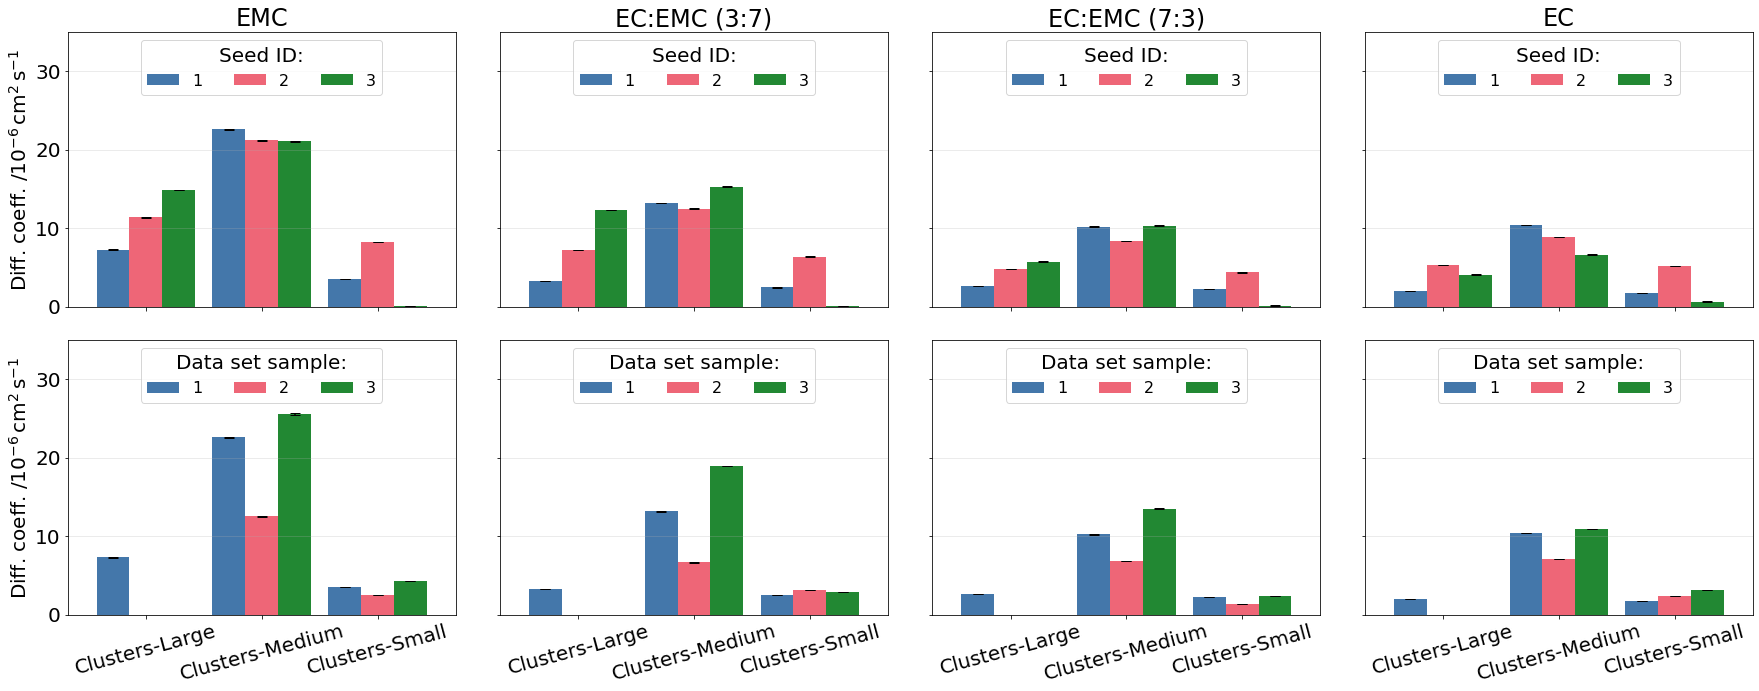

In [131]:
order = [
    'EMC',
    'EC:EMC (3:7)', 
    'EC:EMC (7:3)',
    'EC',
]
wB97X_df = df.copy()[df['Labels'] == 'wB97X-D3']
wB97X_df['Composition'] = pd.Categorical(wB97X_df['Composition'], categories=order, ordered=True)
wB97X_df = wB97X_df.sort_values('Composition')


fig, axs = plt.subplots(2,4, figsize=(10*scale, 4*scale), sharey='row', sharex='col')

seed_df = wB97X_df[wB97X_df['Sample ID'] == 1]
for ax, (n,g) in zip(axs[0,:], seed_df.groupby('Composition',observed=False)):
    avg_g = g.pivot(
        index='Data set',
        columns='Seed ID',
        values='Diff. coeff. /1e6 cm2*s-1',
    )
    std_g = g.pivot(
        index='Data set',
        columns='Seed ID',
        values='Density std. /g*cm-3',
    )
    a0 = avg_g.plot.bar(
        title=n,
        ylim=[0,35],
        ylabel=f'Diff. coeff. /$10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
        yerr=std_g,
        capsize=5,
        rot=15,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Seed ID:', ncols=3, loc='upper center', fontsize=fsize-4)


sample_df = wB97X_df[wB97X_df['Seed ID'] == 1]
for ax, (n,g) in zip(axs[1,:], sample_df.groupby('Composition',observed=False)):
    avg_g = g.pivot(
        index='Data set',
        columns='Sample ID',
        values='Diff. coeff. /1e6 cm2*s-1',
    )
    std_g = g.pivot(
        index='Data set',
        columns='Sample ID',
        values='Diff. fit slope error /1e6 cm2*s-1',
    )
    a1 = avg_g.plot.bar(
        ylim=[0,35],
        xlabel='',
        ylabel=f'Diff. coeff. /$10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
        yerr=std_g,
        capsize=5,
        rot=15,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Data set sample:', ncols=3, loc='upper center', fontsize=fsize-4)

plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_diffusivities.pdf', format='pdf', dpi=1200)

### Effect of change of DFT functional

In [154]:
B97_df = df.copy()[df['Labels'] == 'B97-D3']
wB97X_seed1_df = wB97X_df.copy()[wB97X_df['Seed ID'] == 1]
B97_v_wB97X = pd.concat([B97_df, wB97X_seed1_df])

Clusters-Small:

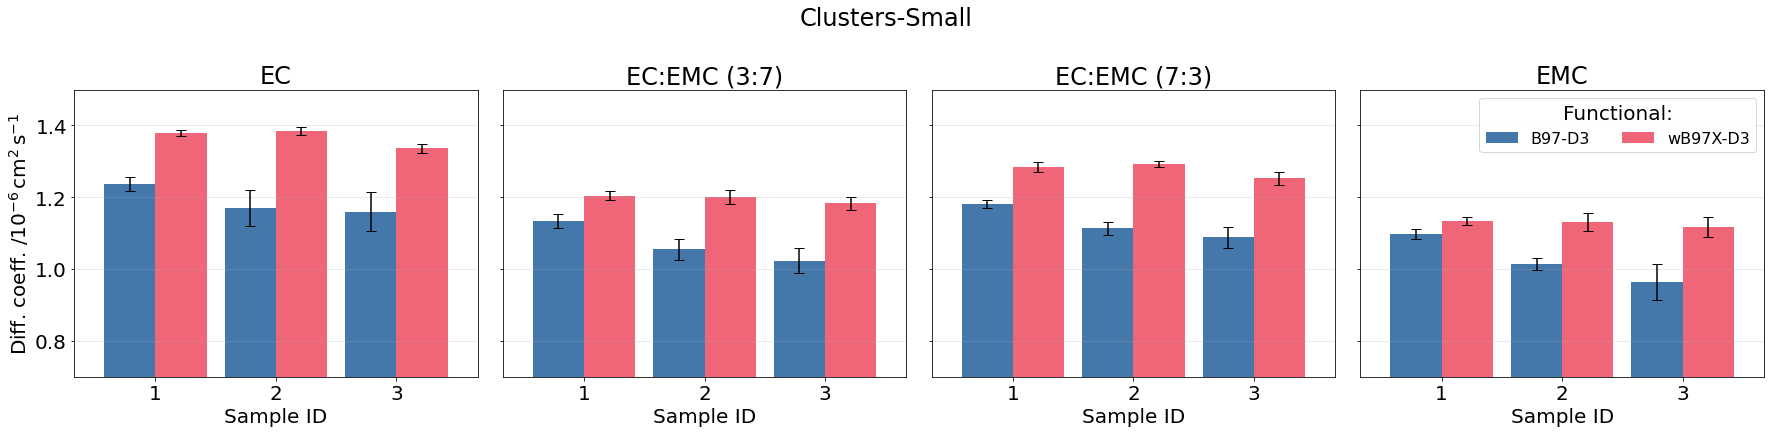

In [157]:
fig, axs = plt.subplots(1,4, figsize=(10*scale, 2.5*scale), sharey=True)



B97_v_wB97X_small = B97_v_wB97X[B97_v_wB97X['Data set'] == 'Clusters-Small'].drop('Seed ID', axis=1)

fig.suptitle('Clusters-Small')
for ax, (n,g) in zip(axs, B97_v_wB97X_small.groupby('Composition', observed=False)):
    ax.set_title(n)
    avg_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Density /g*cm-3',
    )
    std_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Diff. fit slope error /1e6 cm2*s-1',
    )
    a1 = avg_g.plot.bar(
        ylim=[0.7,1.5],
        ylabel=f'Diff. coeff. /$10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
        yerr=std_g,
        capsize=5,
        color=cset,
        rot=0,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)

axs[-1].legend(title='Functional:', ncols=3, loc='upper right', fontsize=fsize-4)
plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_density_func-comp_small.pdf', format='pdf', dpi=1200)

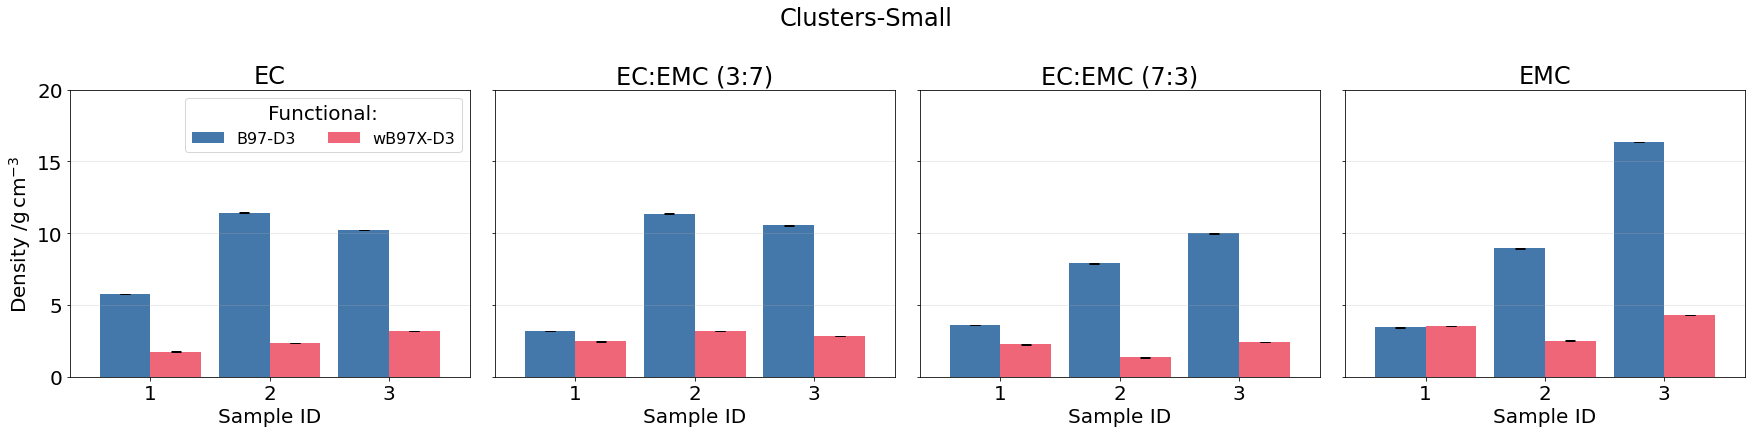

In [160]:
fig, axs = plt.subplots(1,4, figsize=(10*scale, 2.5*scale), sharey=True)



B97_v_wB97X_small = B97_v_wB97X[B97_v_wB97X['Data set'] == 'Clusters-Small'].drop('Seed ID', axis=1)

fig.suptitle('Clusters-Small')
for ax, (n,g) in zip(axs, B97_v_wB97X_small.groupby('Composition', observed=False)):
    ax.set_title(n)
    avg_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Diff. coeff. /1e6 cm2*s-1',
    )
    std_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Density std. /g*cm-3',
    )
    a1 = avg_g.plot.bar(
        ylim=[0,20],
        ylabel=f'Density /g$\\,$cm$^{{-3}}$',
        yerr=std_g,
        capsize=5,
        color=cset,
        rot=0,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)

axs[0].legend(title='Functional:', ncols=3, loc='upper right', fontsize=fsize-4)
plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_diffusivity_func-comp_small.pdf', format='pdf', dpi=1200)

Clusters-Medium:

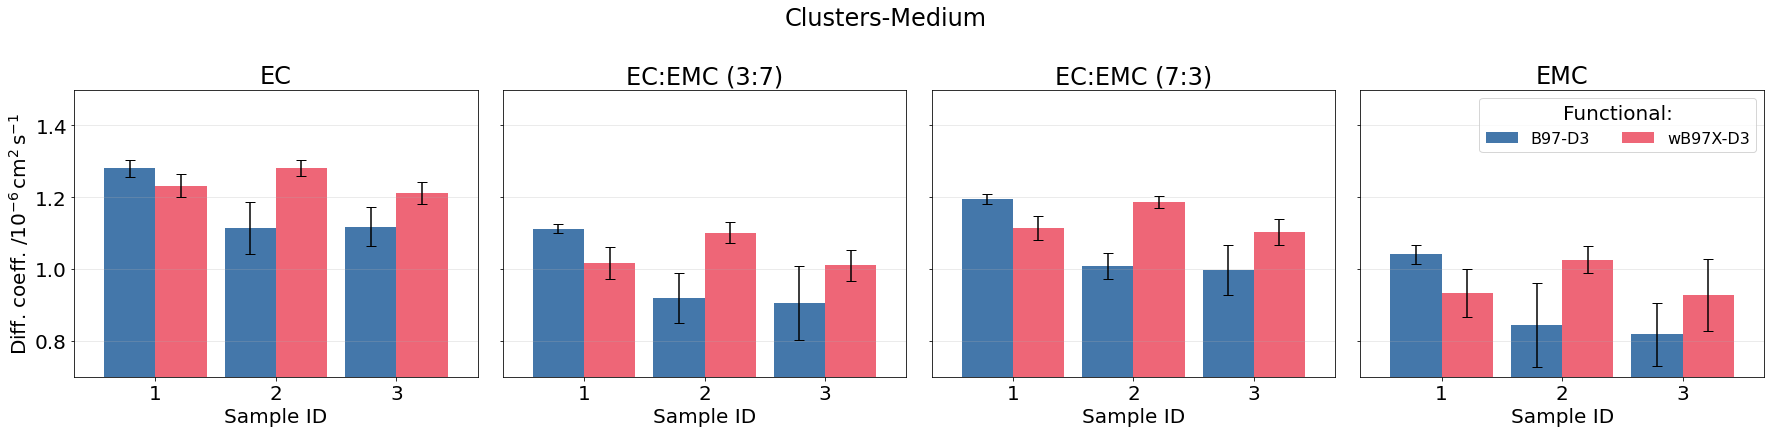

In [165]:
fig, axs = plt.subplots(1,4, figsize=(10*scale, 2.5*scale), sharey=True)



B97_v_wB97X_small = B97_v_wB97X[B97_v_wB97X['Data set'] == 'Clusters-Medium'].drop('Seed ID', axis=1)

fig.suptitle('Clusters-Medium')
for ax, (n,g) in zip(axs, B97_v_wB97X_small.groupby('Composition', observed=False)):
    ax.set_title(n)
    avg_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Density /g*cm-3',
    )
    std_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Diff. fit slope error /1e6 cm2*s-1',
    )
    a1 = avg_g.plot.bar(
        ylim=[0.7,1.5],
        ylabel=f'Diff. coeff. /$10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
        yerr=std_g,
        capsize=5,
        color=cset,
        rot=0,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)

axs[-1].legend(title='Functional:', ncols=3, loc='upper right', fontsize=fsize-4)
plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_density_func-comp_medium.pdf', format='pdf', dpi=1200)

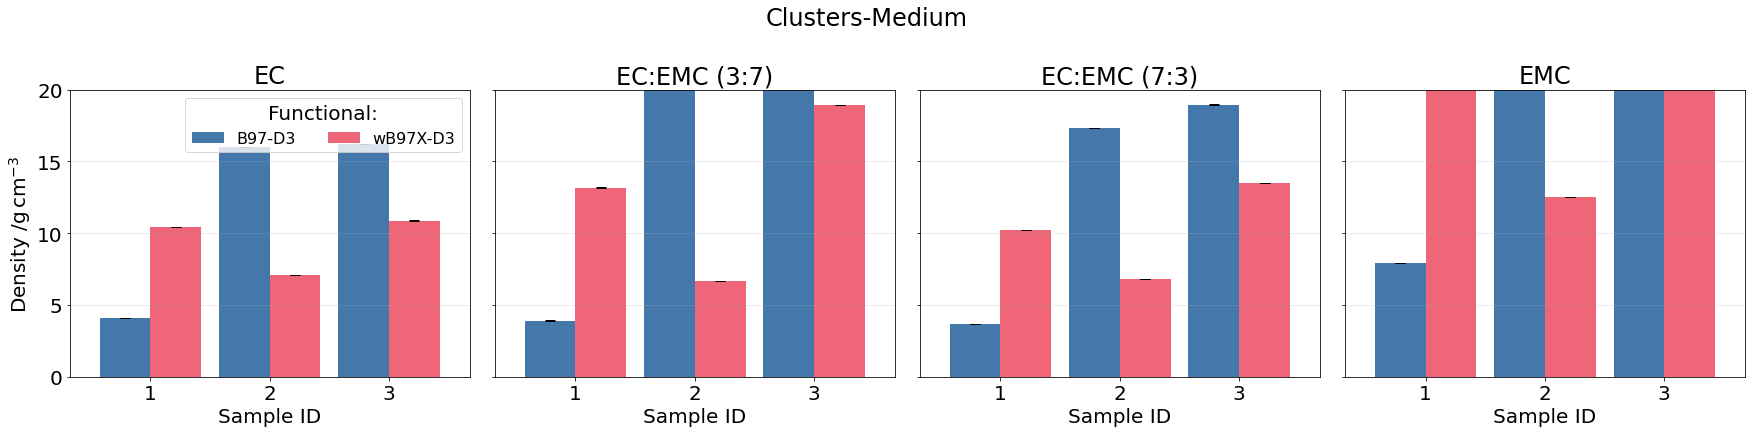

In [164]:
fig, axs = plt.subplots(1,4, figsize=(10*scale, 2.5*scale), sharey=True)



B97_v_wB97X_small = B97_v_wB97X[B97_v_wB97X['Data set'] == 'Clusters-Medium'].drop('Seed ID', axis=1)

fig.suptitle('Clusters-Medium')
for ax, (n,g) in zip(axs, B97_v_wB97X_small.groupby('Composition', observed=False)):
    ax.set_title(n)
    avg_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Diff. coeff. /1e6 cm2*s-1',
    )
    std_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Density std. /g*cm-3',
    )
    a1 = avg_g.plot.bar(
        ylim=[0,20],
        ylabel=f'Density /g$\\,$cm$^{{-3}}$',
        yerr=std_g,
        capsize=5,
        color=cset,
        rot=0,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)

axs[0].legend(title='Functional:', ncols=3, loc='upper right', fontsize=fsize-4)
plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_diffusivity_func-comp_medium.pdf', format='pdf', dpi=1200)

## Structural comparison between periodic- and cluster-based training sets

In [6]:

cluster_inter_pkl = './cluster_inter_rdfs.pkl'
MD_inter_pkl = './MD_inter_rdfs.pkl'
rmax = 10
nbins = 100
cluster_rdfs = {}
cluster_nbrs = {}

Read MD trajectories:

In [7]:
ref_trajs = get_all_thermo(path+'Periodic/PBED3/SEED1/DSET1/dynamics/*', handle='.xyz')

../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz
../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz
../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz
../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz


Compute average neighbour distributions/RDFs and save as pickle:

In [ ]:
reference_coordination = average_nbr_distribution(ref_trajs, rmax=rmax, nbins=nbins, inter_only=True, use_max=False, pbc=True) # Must be rerun!

with open(MD_inter_pkl, 'wb') as f:
    pickle.dump(reference_coordination, f)
    f.close()

Read average neighbour distributions/RDFs saved as pickle:

In [7]:
# Load cached MD reference data
with open(MD_inter_pkl, 'rb') as f:
    reference_coordination =  pickle.load(f)
    f.close()
g_ref_inter, r_ref_inter, rho_ref_inter = reference_coordination['RDF']
n_ref_inter, r_ref_inter = reference_coordination['Nbrs']

Read xyz data and filter according to cluster sizes. Note that for the small and medium datasets, only the first dataset is selected here. Since Clusters-Large contains all clusters there are none left out in this analysis.

In [ ]:
import pickle

print('Reading Clusters-Small...')
with open(small_pkl, 'rb') as f:
    clusters_small_dict = pickle.load(f)
clusters_small_xyz = [a for a in clusters_small_dict['Clusters-Small-1'] if a.info['Nmols'] > 1]

print('Reading Clusters-Medium...')
with open(medium_pkl, 'rb') as f:
    clusters_medium_dict = pickle.load(f)
clusters_medium_xyz = [a for a in clusters_medium_dict['Clusters-Medium-1'] if a.info['Nmols'] > 1]

print('Reading Clusters-Large...')
with open(large_pkl, 'rb') as f:
    clusters_large_dict = pickle.load(f)
clusters_large_xyz = [a for a in clusters_large_dict['Clusters-Large'] if a.info['Nmols'] > 1]

print('Done!')

Compute average neighbour distributions/RDFs and save as pickle:

In [15]:
print('Neighbour distributions:')
print('Clusters-Large')
cluster_nbrs['Clusters-Large'] = compute_rdf(clusters_large_xyz, rmax=rmax, nbins=nbins, use_max=False, inter_only=True, nbr_density=True, return_rho=False, pbc=False)
print('Clusters-Medium')
cluster_nbrs['Clusters-Medium'] = compute_rdf(clusters_medium_xyz, rmax=rmax, nbins=nbins, use_max=False, inter_only=True, nbr_density=True, return_rho=False, pbc=False)
print('Clusters-small')
cluster_nbrs['Clusters-Small'] = compute_rdf(clusters_small_xyz, rmax=rmax, nbins=nbins, use_max=False, inter_only=True, nbr_density=True, return_rho=False, pbc=False)

print('RDFs:')
print('Clusters-Large, max')
cluster_rdfs['Clusters-Large-max'] = compute_rdf(clusters_large_xyz, rmax=rmax, nbins=nbins, rho=rho_ref_inter, use_max=True, inter_only=True, nbr_density=False, return_rho=False, pbc=False)
print('Clusters-Large, mean')
cluster_rdfs['Clusters-Large-mean'] = compute_rdf(clusters_large_xyz, rmax=rmax, nbins=nbins, rho=rho_ref_inter, use_max=False, inter_only=True, nbr_density=False, return_rho=False, pbc=False)

print('Done!')
coordinations = {'RDF':cluster_rdfs, 'Nbrs':cluster_nbrs}
with open(cluster_inter_pkl, 'wb') as f:
    pickle.dump(coordinations, f)
    f.close()

Neighbour distributions:
Clusters-Large
Clusters-Medium
Clusters-small
RDFs:
Clusters-Large, max
Clusters-Large, mean
Done!


Read neighbour distributions/RDFs of clusters saved as pickle:

In [8]:
# Load cached cluster data
with open(cluster_inter_pkl, 'rb') as f:
    coordinations = pickle.load(f)
    f.close()
cluster_rdfs = coordinations['RDF']
cluster_nbrs = coordinations['Nbrs']

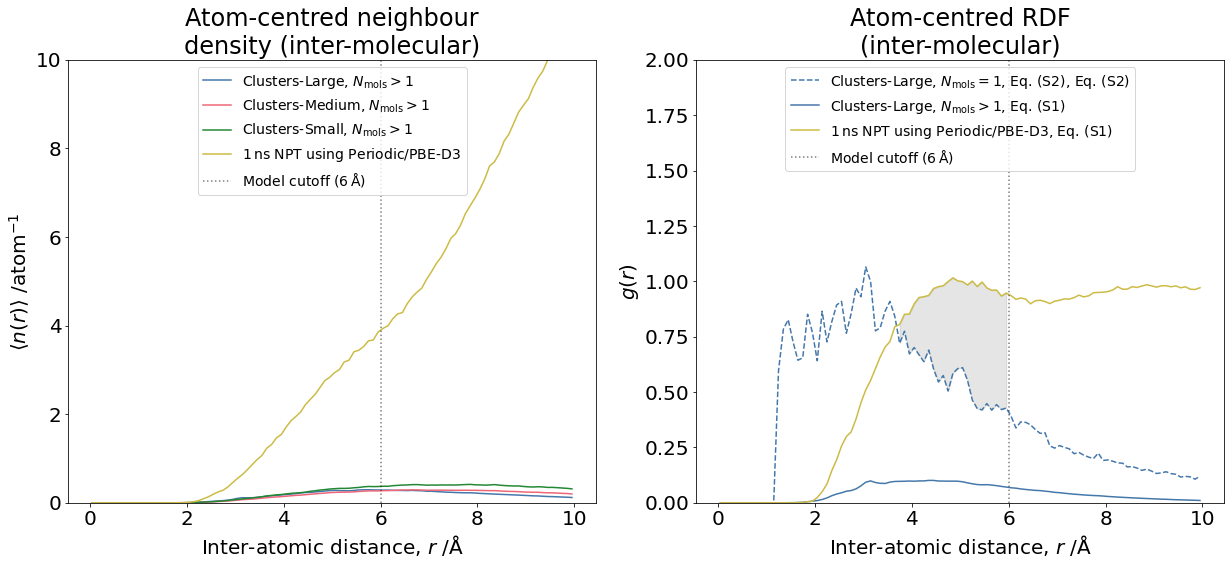

In [ ]:
name_map = {
    'Clusters-Large-max':'Clusters-Large, $N_\\text{mols}=1$, Eq. (S2)',
    'Clusters-Large-mean':'Clusters-Large, $N_\\text{mols}>1$, Eq. (S1)',
    'Clusters-Large':'Clusters-Large, $N_\\text{mols}>1$',
    'Clusters-Medium':'Clusters-Medium, $N_\\text{mols}>1$',
    'Clusters-Small':'Clusters-Small, $N_\\text{mols}>1$',
}


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7*scale, 3.3*scale), sharey=False)
ax1.set_title('Atom-centred neighbour\ndensity (inter-molecular)')
ax1.set_ylim([None,10])
ax1.set_xlabel('Inter-atomic distance, $r$ /Å')
ax1.set_ylabel('$\\langle n(r) \\rangle$ /atom$^{-1}$')
for name, data in cluster_nbrs.items():
    n, r = data
    ax1.plot(r,n, '-', label=name_map[name])

ax1.plot(r_ref_inter,n_ref_inter, color=cset[3], label='1$\\,$ns NPT using Periodic/PBE-D3')
ax1.axvline(x=6.0, linestyle=':', color=cset.black, alpha=0.5, label='Model cutoff (6$\\,$Å)')
ax1.legend(loc='upper center', fontsize=fsize-6)

ax2.set_title('Atom-centred RDF\n(inter-molecular)')
ax2.set_xlabel('Inter-atomic distance, $r$ /Å')
ax2.set_ylabel('$g(r)$')
ax2.set_ylim([None,2])
for name, data in cluster_rdfs.items():
    g, r = data    
    if 'mean' in name:
        g_mean = g
        ax2.plot(r,g_mean, '-', color=cset.blue, label=name_map[name])
    elif 'max' in name:
        g_max = g
        ax2.plot(r,g_max, '--', color=cset.blue, label=name_map[name]+', Eq. (S2)')
    
ax2.fill_between(r[r<=6], g_max[r<=6], g_ref_inter[r<=6], g_max[r<=6]<g_ref_inter[r<=6], color=cset.black, alpha=0.1)


ax2.plot(r_ref_inter,g_ref_inter, color=cset[3], label='1$\\,$ns NPT using Periodic/PBE-D3, Eq. (S1)')
ax2.axvline(x=6.0, linestyle=':', color=cset.black, alpha=0.5, label='Model cutoff (6$\\,$Å)')
ax2.legend(loc='upper center', fontsize=fsize-6)

plt.tight_layout()
plt.savefig('./part2_pair-coordination.pdf', format='pdf', dpi=1200)

## Structural properties of liquids

In [ ]:
def eval_rdfs(tags, traj_path, slice=':'):
    import glob
    rdfs = {}
    number_densities = {}
    for tag in tags:
        data_set, functional, seed, dset_sample = tag.split('/')
        flist = [name for name in glob.glob(f'{traj_path}{tag}/dynamics/*') if '.xyz' in name]
        name = f'{data_set}_{functional}'
        print(name, dset_sample, seed)

        for file in flist:
            comp = file.split('/')[-1].split('.')[0]
            print(comp)
            traj = read(file, slice)
            aa.find_molecs(traj, fct=1.0)
            g, r, rho = compute_rdf(traj, rmax=11, return_rho=True)

            if name not in rdfs:
                rdfs[name] = {}
            if dset_sample not in rdfs[name]:
                rdfs[name][dset_sample] = {}
            if seed not in rdfs[name][dset_sample]:
                rdfs[name][dset_sample][seed] = {}
            
            if name not in number_densities:
                number_densities[name] = {}
            if dset_sample not in number_densities[name]:
                number_densities[name][dset_sample] = {}
            if seed not in number_densities[name][dset_sample]:
                number_densities[name][dset_sample][seed] = {}

            rdfs[name][dset_sample][seed][comp] = [g, r]
            number_densities[name][dset_sample][seed][comp] = rho
            del traj
    
    return rdfs, number_densities

Compute RDFs and save as pickle:

In [ ]:
rdfs, number_densities = eval_rdfs(tags, path)

with open('./part2_rdfs.pkl', 'wb') as f:
    pickle.dump(rdfs, f)

with open('./part2_rhos.pkl', 'wb') as f:
    pickle.dump(number_densities, f)

Read RDFs from pickle:

In [ ]:
with open('./part2_rdfs.pkl', 'rb') as f:
    rdfs = pickle.load(f)

with open('./part2_rhos.pkl', 'rb') as f:
    number_densities = pickle.load(f)

In [ ]:
rstart = 6
id_width = 20

radii = []
for model,dsets in rdfs.items():
    for dset,seeds in dsets.items():
        for seed,comps in seeds.items():
            for comp, (g, r) in comps.items():
                temp = int(comp.split('_')[1:][-1][:-1])

                id0 = np.where(r>rstart)[0][0]
                
                idhi = id0+id_width
                rmin = min(r[id0:idhi])
                idx = np.argmin(g[id0:idhi])
                
                rho = number_densities[model][dset][seed][comp]
                r_prime = r[:id0+idx]
                g_prime = g[1:id0+idx]                        
                v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                N = sum(g_prime*v_shell*rho)
                train_data, functional = model.split('_')
                
                radii.append([train_data, functional, seed, dset, traj_map[comp], temp, r[id0+idx], N])

radii_df = pd.DataFrame(radii, columns=['Train data', 'Functional', 'Seed', 'Sample', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df['Train data'] = radii_df['Train data'].map(data_map)
for name, group in radii_df.groupby('Train data'):
    print('Average first shell coordinations:')
    print(name, group['CN'].mean(), '\n')
radii_df

,Train data,Functional,Seed,Sample,Composition,Temperature,Rmin,CN


In [ ]:
cn_df = radii_df.copy().drop('Functional', axis=1)

seed_cn_df = cn_df.copy()
seed_cn_agg_df = seed_cn_df.groupby(['Train data', 'Composition', 'Sample'], as_index=False).agg(
    mean_value=('CN', 'mean'),
    std_value=('CN', 'std')
).dropna().drop('Sample', axis=1)

sample_cn_df = cn_df.copy()
sample_cn_agg_df = sample_cn_df.groupby(['Train data', 'Composition', 'Seed'], as_index=False).agg(
    mean_value=('CN', 'mean'),
    std_value=('CN', 'std')
).dropna().drop('Seed', axis=1)

In [ ]:

order = [
    'EMC',
    'EC:EMC (3:7)', 
    'EC:EMC (7:3)',
    'EC',
]
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(6*scale,3*scale), sharey=True)
fig.suptitle('Intermolecular first shell coordinations after 1$\\,$ns NPT')

seed_avg_df = seed_cn_agg_df.pivot(
	index='Train data',
	columns='Composition',
	values='mean_value',
).sort_index(axis=0,ascending=False)[order]
seed_std_df = seed_cn_agg_df.pivot(
	index='Train data',
	columns='Composition',
	values='std_value',
).sort_index(axis=0,ascending=False)[order]
seed_avg_df.plot.bar(
    ax=ax1,
    color=[get_colour(o) for o in order],
    ylim=[7,14],
    yerr=seed_std_df,
    capsize=5,
    rot=15,
    legend=False,
    xlabel='',
    width=0.85,
)
ax1.set_title('Average over seeds', fontsize=fsize-1)
ax1.set_ylabel('Coordination number', fontsize=fsize-1)
ax1.grid(axis='y', alpha=0.3)

#ax1.legend(loc='upper right')



sample_avg_df = sample_cn_agg_df.pivot(
	index='Train data',
	columns='Composition',
	values='mean_value',
).sort_index(axis=0,ascending=False)[order]
sample_std_df = sample_cn_agg_df.pivot(
	index='Train data',
	columns='Composition',
	values='std_value',
).sort_index(axis=0,ascending=False)[order]

sample_avg_df.plot.bar(
    ax=ax2,
    color=[get_colour(o) for o in order],
    yerr=seed_std_df,
    capsize=5,
    rot=15,
    legend=False,
    xlabel='',
    width=0.5,
)
ax2.set_title('Average over data set samples', fontsize=fsize-5)
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)

#plt.savefig('../publication/plots/SI/part2_first-shell-cn.pdf', format='pdf', dpi=1200)

/tmp/ipykernel_252284/2096424873.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(fontsize=fsize-4)


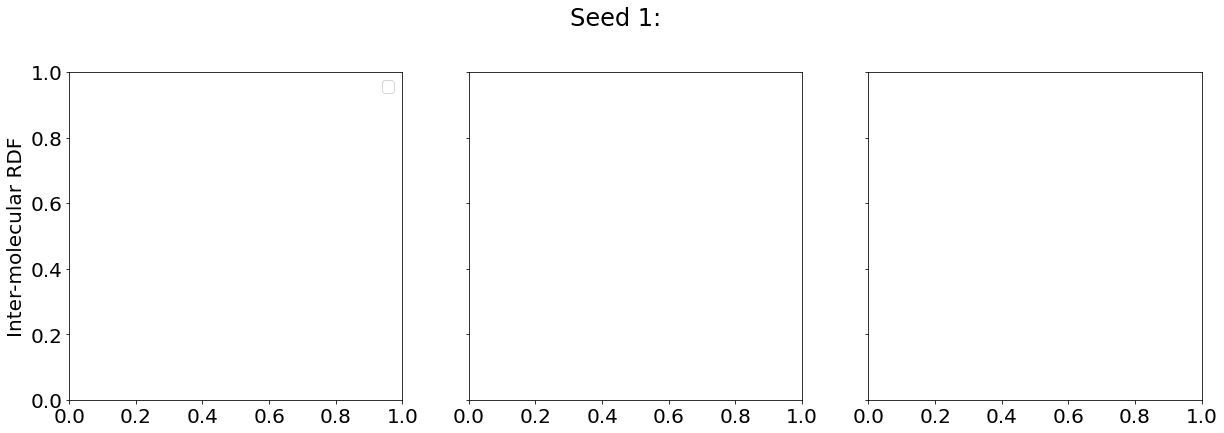

In [ ]:
model_map = {
    'SDN22N_wB97X':'Clusters-Large',
    'SDN22NQ_wB97X':'Clusters-Medium',
    'SDN22NQQ_wB97X':'Clusters-Small',
    'IBM23':'Periodic',
}

rstart = 6
id_width = 20

radii = []
fig, axs = plt.subplots(1,3, figsize=(7*scale,2.5*scale), sharey=True)
fig.suptitle('Seed 1:')
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    ax.set_title(model_map[model])
    ax.set_xlabel('Inter-molecular distance /Å')
    #print(model)
    for dset,seeds in dsets.items():
        #print(dset)
        
        if dset == 'DSET1':
            for seed,comps in seeds.items():
                if seed == 'SEED1':
                    #print(seed)
                    for comp, (g, r) in comps.items():
                        #print(comp)
                        id0 = np.where(r>rstart)[0][0]
                        temp = int(comp.split('_')[1:][-1][:-1])

                        #print(id0, r[id0])
                        print(comp)
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])
                        #print(idx, r[idx])

                        ax.axvline(r[id0+idx], 0, 1, color=get_colour(comp), alpha=1, linestyle='dotted')
                        #ax.axvspan(r[id0], r[idhi],alpha=0.05, color='gray')
                        ax.plot(r, g, label=traj_map[comp], color=get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.1)

                        
                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, functional = model.split('_')
                        radii.append([train_data, functional, seed, dset, traj_map[comp], temp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-4)
plt.tight_layout()


radii_df = pd.DataFrame(radii, columns=['Train data', 'Functional', 'Seed', 'Sample', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df['Train data'] = radii_df['Train data'].map(data_map)
radii_df = radii_df.drop('Seed', axis=1)
radii_df = radii_df.drop('Sample', axis=1)
radii_df = radii_df.drop('Temperature', axis=1)
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Train data'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')

In [ ]:
rstart = 6
id_width = 20

radii = []
fig, axs = plt.subplots(1,3, figsize=(7*scale,2.5*scale), sharey=True)
fig.suptitle('Seed 2:')
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    ax.set_title(model_map[model])
    ax.set_xlabel('Inter-molecular distance /Å')
    #print(model)
    for dset,seeds in dsets.items():
        #print(dset)
        if dset == 'DSET1':
            for seed,comps in seeds.items():
                if seed == 'SEED2':
                    #print(seed)
                    for comp, (g, r) in comps.items():
                        #print(comp)
                        id0 = np.where(r>rstart)[0][0]
                        temp = int(comp.split('_')[1:][-1][:-1])

                        #print(id0, r[id0])
                        
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])
                        #print(idx, r[idx])

                        ax.axvline(r[id0+idx], 0, 1, color=get_colour(comp), alpha=1, linestyle='dotted')
                        #ax.axvspan(r[id0], r[idhi],alpha=0.05, color='gray')
                        ax.plot(r, g, label=tmap[comp], color=get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.1)
                        
                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, functional = model.split('_')
                        radii.append([train_data, functional, seed, dset, tmap[comp], temp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-4)
plt.tight_layout()

radii_df = pd.DataFrame(radii, columns=['Train data', 'Functional', 'Seed', 'Sample', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df['Train data'] = radii_df['Train data'].map(data_map)
radii_df = radii_df.drop('Seed', axis=1)
radii_df = radii_df.drop('Sample', axis=1)
radii_df = radii_df.drop('Temperature', axis=1)
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Train data'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')


In [ ]:
rstart = 6
id_width = 20

radii = []
fig, axs = plt.subplots(1,3, figsize=(6*scale,2.5*scale), sharey=True)
fig.suptitle('Seed 3:')
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    ax.set_title(model_map[model])
    ax.set_xlabel('Inter-molecular distance /Å')
    #print(model)
    for dset,seeds in dsets.items():
        #print(dset)
        if dset == 'DSET1':
            for seed,comps in seeds.items():
                if seed == 'SEED3':
                    #print(seed)
                    for comp, (g, r) in comps.items():
                        #print(comp)
                        id0 = np.where(r>rstart)[0][0]
                        temp = int(comp.split('_')[1:][-1][:-1])

                        #print(id0, r[id0])
                        
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])
                        #print(idx, r[idx])

                        ax.axvline(r[id0+idx], 0, 1, color=get_colour(comp), alpha=1, linestyle='dotted')
                        #ax.axvspan(r[id0], r[idhi],alpha=0.05, color='gray')
                        ax.plot(r, g, label=tmap[comp], color=get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.1)
                        
                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, functional = model.split('_')
                        radii.append([train_data, functional, seed, dset, tmap[comp], temp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-4)
plt.tight_layout()

radii_df = pd.DataFrame(radii, columns=['Train data', 'Functional', 'Seed', 'Sample', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df['Train data'] = radii_df['Train data'].map(data_map)
radii_df = radii_df.drop('Seed', axis=1)
radii_df = radii_df.drop('Sample', axis=1)
radii_df = radii_df.drop('Temperature', axis=1)
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Train data'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')

In [ ]:
rstart = 6
id_width = 20

radii = []
fig, axs = plt.subplots(1,2, figsize=(14/3*scale,2.5*scale), sharey=True)
fig.suptitle('Data set sample 2:')
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    ax.set_title(model_map[model])
    ax.set_xlabel('Inter-molecular distance /Å')
    #print(model)
    for dset,seeds in dsets.items():
        #print(dset)
        if dset == 'DSET2':
            for seed,comps in seeds.items():
                if seed == 'SEED1':
                    #print(seed)
                    for comp, (g, r) in comps.items():
                        #print(comp)
                        id0 = np.where(r>rstart)[0][0]
                        temp = int(comp.split('_')[1:][-1][:-1])

                        #print(id0, r[id0])
                        
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])
                        #print(idx, r[idx])

                        ax.axvline(r[id0+idx], 0, 1, color=get_colour(comp), alpha=1, linestyle='dotted')
                        #ax.axvspan(r[id0], r[idhi],alpha=0.05, color='gray')
                        ax.plot(r, g, label=tmap[comp], color=get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.1)
                        
                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, functional = model.split('_')
                        radii.append([train_data, functional, seed, dset, tmap[comp], temp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-4)
plt.tight_layout()

radii_df = pd.DataFrame(radii, columns=['Train data', 'Functional', 'Seed', 'Sample', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df['Train data'] = radii_df['Train data'].map(data_map)
radii_df = radii_df.drop('Seed', axis=1)
radii_df = radii_df.drop('Sample', axis=1)
radii_df = radii_df.drop('Temperature', axis=1)
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Train data'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')

In [ ]:
rstart = 6
id_width = 20

radii = []
fig, axs = plt.subplots(1,2, figsize=(14/3*scale,2.5*scale), sharey=True)
fig.suptitle('Data set sample 2:')
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    ax.set_title(model_map[model])
    ax.set_xlabel('Inter-molecular distance /Å')
    #print(model)
    for dset,seeds in dsets.items():
        #print(dset)
        if dset == 'DSET3':
            for seed,comps in seeds.items():
                if seed == 'SEED1':
                    #print(seed)
                    for comp, (g, r) in comps.items():
                        #print(comp)
                        id0 = np.where(r>rstart)[0][0]
                        temp = int(comp.split('_')[1:][-1][:-1])
                        
                        #print(id0, r[id0])
                        
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])
                        #print(idx, r[idx])

                        ax.axvline(r[id0+idx], 0, 1, color=get_colour(comp), alpha=1, linestyle='dotted')
                        #ax.axvspan(r[id0], r[idhi],alpha=0.05, color='gray')
                        ax.plot(r, g, label=tmap[comp], color=get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.1)

                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, functional = model.split('_')
                        radii.append([train_data, functional, seed, dset, tmap[comp], temp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-4)
plt.tight_layout()

radii_df = pd.DataFrame(radii, columns=['Train data', 'Functional', 'Seed', 'Sample', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df['Train data'] = radii_df['Train data'].map(data_map)
radii_df = radii_df.drop('Seed', axis=1)
radii_df = radii_df.drop('Sample', axis=1)
radii_df = radii_df.drop('Temperature', axis=1)
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Train data'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')